<a href="https://colab.research.google.com/github/seongwoojang1123/Effusion-OSA-TMD/blob/main/3_Logistic_Regression_Training_Effusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.multiclass import OneVsRestClassifier
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy import stats

file_path = '/content/drive/MyDrive/Effusion OSA TMD/20250831_Effusion_TMD_Pain_Data.xlsx'

df = pd.read_excel(file_path, sheet_name='20250830_20250829_20250226_2024')

Effusion(0,1) ROC with Color + 95% CI

AUROC: 0.841
AUROC 95% CI: [0.703, 0.949]
P-value (AUC > 0.5): 3.304e-08
Incidence Rate (Effusion=1 비율): 0.697


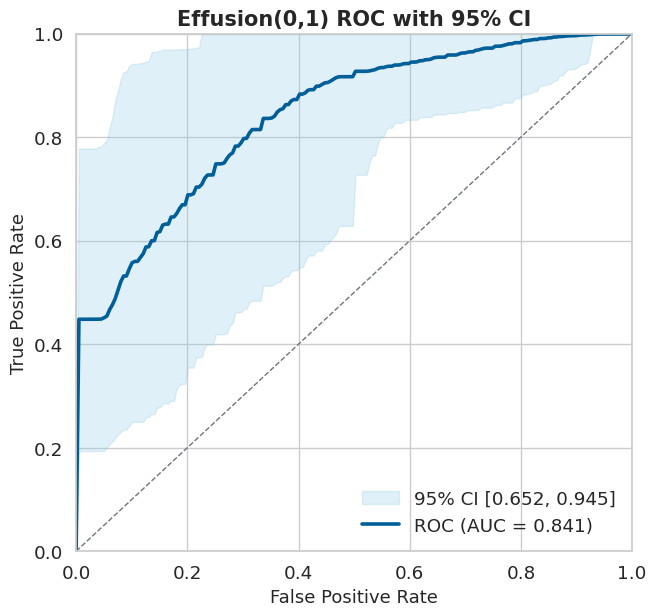


Summary:
 AUROC  AUROC_95CI_Lower  AUROC_95CI_Upper  P_value_(AUC>0.5)  IR_(Effusion=1_ratio)
 0.841             0.703             0.949       3.304000e-08                  0.697


In [17]:

y = df['Effusion']
X = df.iloc[:, 3:15].fillna(0)  # Age ~ Bruxism

# ------------------------------------------------------------
# 1) Train/Test split + Scaling
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ------------------------------------------------------------
# 2) Model Training (Logistic Regression)
# ------------------------------------------------------------
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# 3) AUROC
# ------------------------------------------------------------
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("AUROC:", round(roc_auc, 3))

# ------------------------------------------------------------
# 4) AUROC 95% CI (bootstrap on AUC)
# ------------------------------------------------------------
n_bootstraps = 2000
rng = np.random.RandomState(42)
boot_auc = []

for _ in range(n_bootstraps):
    idx = rng.randint(0, len(y_test), len(y_test))
    y_bs = y_test.iloc[idx]
    p_bs = y_pred_proba[idx]

    if len(np.unique(y_bs)) < 2:
        continue
    boot_auc.append(roc_auc_score(y_bs, p_bs))

boot_auc = np.array(boot_auc)
ci_lower = np.percentile(boot_auc, 2.5)
ci_upper = np.percentile(boot_auc, 97.5)
print(f"AUROC 95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

# p-value (H0: AUC=0.5)
z_stat = (roc_auc - 0.5) / (np.std(boot_auc, ddof=1) + 1e-12)
p_value = 1 - stats.norm.cdf(z_stat)
print("P-value (AUC > 0.5):", f"{p_value:.4g}")

# Incidence Rate
IR = y.mean()
print("Incidence Rate (Effusion=1 비율):", f"{IR:.3f}")

# ------------------------------------------------------------
# 5) ROC Curve + 95% CI Band
# ------------------------------------------------------------
# (a) test ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

# (b) bootstrap ROC → CI band
fpr_grid = np.linspace(0, 1, 200)
tprs = []

for _ in range(n_bootstraps):
    idx = rng.randint(0, len(y_test), len(y_test))
    y_bs = y_test.iloc[idx]
    p_bs = y_pred_proba[idx]
    if len(np.unique(y_bs)) < 2:
        continue
    fpr_bs, tpr_bs, _ = roc_curve(y_bs, p_bs)

    tpr_interp = np.interp(fpr_grid, fpr_bs, tpr_bs)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)

tprs = np.array(tprs)
tpr_mean  = tprs.mean(axis=0)
tpr_lower = np.percentile(tprs, 2.5, axis=0)
tpr_upper = np.percentile(tprs, 97.5, axis=0)

# (c) Plot
plt.figure(figsize=(6.8, 6.4))

# 95% CI band
plt.fill_between(
    fpr_grid, tpr_lower, tpr_upper,
    color="#8ecae6", alpha=0.28, label="95% CI [0.652, 0.945]"
)

# average ROC
plt.plot(fpr_grid, tpr_mean, color="#005f99", lw=2.6,
         label=f"ROC (AUC = {roc_auc:.3f})")


plt.plot([0, 1], [0, 1], "--", color="#6c757d", lw=1)

plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("Effusion(0,1) ROC with 95% CI", fontsize=15, fontweight="bold")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) Summary table for reporting
# ------------------------------------------------------------
summary_df = pd.DataFrame([{
    "AUROC": round(roc_auc, 3),
    "AUROC_95CI_Lower": round(ci_lower, 3),
    "AUROC_95CI_Upper": round(ci_upper, 3),
    "P_value_(AUC>0.5)": float(f"{p_value:.4g}"),
    "IR_(Effusion=1_ratio)": round(IR, 3)
}])
print("\nSummary:")
print(summary_df.to_string(index=False))


Regression coefficient (importance of explanatory variable)

In [3]:
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)

            Variable  Coefficient
4                VAS     0.805841
10           Locking     0.475862
5                 DI     0.419275
8   Symptom duration     0.393316
9          TMJ noise     0.370817
11  Muscle stiffness     0.316279
2                ADD     0.230684
3                 OA     0.221470
0       Sex (Female)     0.173908
7                CMI     0.155209
6                 PI    -0.063105
1                Age    -0.072375


Effusion grade (0/1/2) — OVR ROC with Color + 95% CI

Per-class AUROC: {'class 0': np.float64(0.79), 'class 1': np.float64(0.628), 'class 2': np.float64(0.627)}
Macro AUROC: 0.682
Micro AUROC: 0.677

95% CI (per-class AUC):
  Class 0: [0.620, 0.929]
  Class 1: [0.450, 0.781]
  Class 2: [0.453, 0.789]

95% CI (Macro AUC): [0.557, 0.793]
95% CI (Micro AUC): [0.552, 0.787]


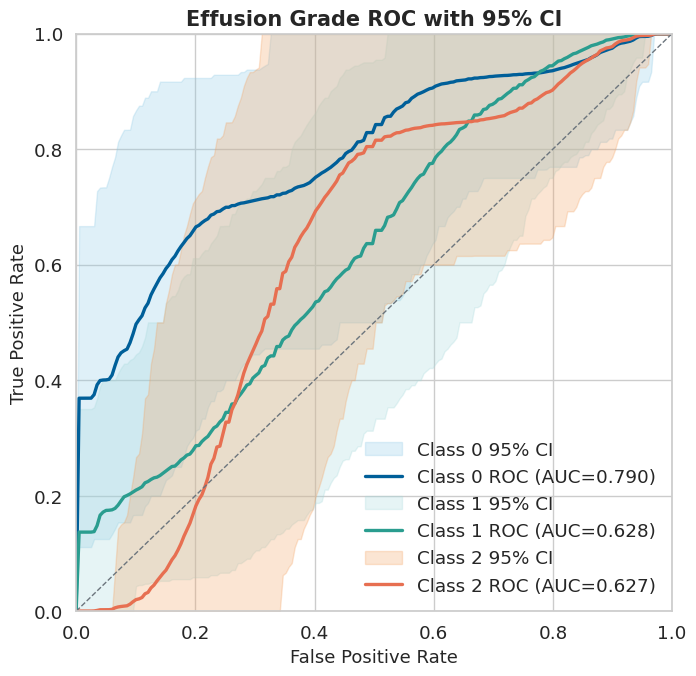


Summary (AUROC with 95% CI):
Class  AUROC  AUROC_95CI_Lower  AUROC_95CI_Upper
    0  0.790             0.620             0.929
    1  0.628             0.450             0.781
    2  0.627             0.453             0.789
Macro  0.682             0.557             0.793
Micro  0.677             0.552             0.787


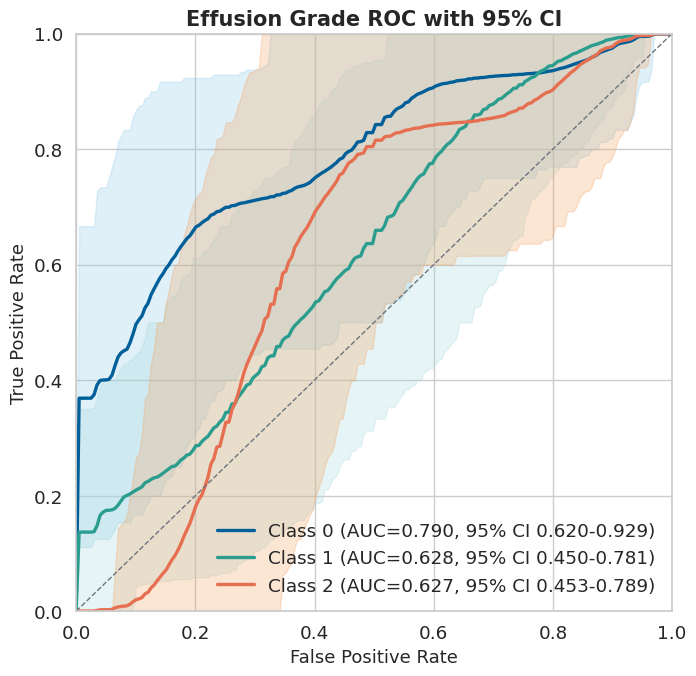

In [6]:

#    - outcome: Effusion grade (0/1/2, C)

X = df.iloc[:, 3:15].fillna(0)
y = df['Effusion grade']
classes = [0, 1, 2]

y_bin_all = label_binarize(y, classes=classes)  # (N, 3)

# ------------------------------------------------------------
# 1) Train/Test split + Scaling
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ------------------------------------------------------------
# 2) Model Training (OVR Logistic Regression)
# ------------------------------------------------------------
clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
clf.fit(X_train_sc, y_train)

y_score = clf.predict_proba(X_test_sc)

y_test_bin = label_binarize(y_test, classes=classes)  # (n, 3)

# ------------------------------------------------------------
# 3) Point estimation AUC
# ------------------------------------------------------------
auc_per_class = {}
for i, c in enumerate(classes):
    auc_per_class[c] = roc_auc_score(y_test_bin[:, i], y_score[:, i])

auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print("Per-class AUROC:", {f"class {c}": round(auc_per_class[c], 3) for c in classes})
print("Macro AUROC:", round(auc_macro, 3))
print("Micro AUROC:", round(auc_micro, 3))

# ------------------------------------------------------------
# 4) 95% CI (bootstrap)
#   - per-class AUC CI
#   - macro/micro AUC CI
#   - per-class ROC CI band (TPR-band vs FPR)
# ------------------------------------------------------------
n_boot = 2000
rng = np.random.RandomState(42)
n = len(y_test)


fpr_grid = np.linspace(0, 1, 200)


boot_auc_per_class = {c: [] for c in classes}
boot_auc_macro = []
boot_auc_micro = []
tprs_band = {c: [] for c in classes}

for _ in range(n_boot):
    idx = rng.randint(0, n, n)
    y_bin_bs = y_test_bin[idx]     # (n, 3)
    y_scr_bs = y_score[idx]        # (n, 3)


    valid_for_macro = True
    per_class_auc_this_boot = []

    for i, c in enumerate(classes):
        y_true_i = y_bin_bs[:, i]
        y_sc_i   = y_scr_bs[:, i]

        if len(np.unique(y_true_i)) < 2:
            valid_for_macro = False
            continue

        # AUC
        auc_i = roc_auc_score(y_true_i, y_sc_i)
        boot_auc_per_class[c].append(auc_i)
        per_class_auc_this_boot.append(auc_i)

        # ROC
        fpr_i, tpr_i, _ = roc_curve(y_true_i, y_sc_i)
        tpr_interp = np.interp(fpr_grid, fpr_i, tpr_i)
        tpr_interp[0] = 0.0
        tprs_band[c].append(tpr_interp)

    # macro/micro AUC
    if valid_for_macro:
        boot_auc_macro.append(roc_auc_score(y_bin_bs, y_scr_bs, average="macro"))
        boot_auc_micro.append(roc_auc_score(y_bin_bs, y_scr_bs, average="micro"))

# CI
def ci_low_high(arr, lo=2.5, hi=97.5):
    arr = np.asarray(arr, dtype=float)
    return np.percentile(arr, lo), np.percentile(arr, hi)

# per-class AUC CI
ci_per_class = {}
for c in classes:
    if len(boot_auc_per_class[c]) > 0:
        lo, hi = ci_low_high(boot_auc_per_class[c])
        ci_per_class[c] = (lo, hi)
    else:
        ci_per_class[c] = (np.nan, np.nan)

# macro/micro AUC CI
if len(boot_auc_macro) > 0:
    macro_lo, macro_hi = ci_low_high(boot_auc_macro)
else:
    macro_lo, macro_hi = (np.nan, np.nan)

if len(boot_auc_micro) > 0:
    micro_lo, micro_hi = ci_low_high(boot_auc_micro)
else:
    micro_lo, micro_hi = (np.nan, np.nan)

print("\n95% CI (per-class AUC):")
for c in classes:
    lo, hi = ci_per_class[c]
    print(f"  Class {c}: [{lo:.3f}, {hi:.3f}]")

print(f"\n95% CI (Macro AUC): [{macro_lo:.3f}, {macro_hi:.3f}]")
print(f"95% CI (Micro AUC): [{micro_lo:.3f}, {micro_hi:.3f}]")

# ------------------------------------------------------------
# 5) ROC Average Curve + 95% CI Band (by Class) Plot
# ------------------------------------------------------------

line_colors = {0: "#005f99", 1: "#2a9d8f", 2: "#e76f51"}
band_colors = {0: "#8ecae6", 1: "#a8dadc", 2: "#f4a261"}

plt.figure(figsize=(7.2, 7.0))

for i, c in enumerate(classes):
    tprs = np.array(tprs_band[c], dtype=float)
    if tprs.size == 0:

        continue
    # Average/CI
    tpr_mean  = np.nanmean(tprs, axis=0)
    tpr_lower = np.nanpercentile(tprs, 2.5, axis=0)
    tpr_upper = np.nanpercentile(tprs, 97.5, axis=0)

    # CI Band
    plt.fill_between(
        fpr_grid, tpr_lower, tpr_upper,
        color=band_colors[c], alpha=0.28, label=f"Class {c} 95% CI"
    )
    # Average ROC Line
    plt.plot(
        fpr_grid, tpr_mean, color=line_colors[c], lw=2.4,
        label=f"Class {c} ROC (AUC={auc_per_class[c]:.3f})"
    )

# Reference diagonal
plt.plot([0,1],[0,1], "--", color="#6c757d", lw=1)

plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("Effusion Grade ROC with 95% CI", fontsize=15, fontweight="bold")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower right", frameon=False, ncol=1)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) Summary Table for Reporting (AUC + 95% CI Figures)
# ------------------------------------------------------------
summary_rows = []
for c in classes:
    lo, hi = ci_per_class[c]
    summary_rows.append({
        "Class": c,
        "AUROC": round(auc_per_class[c], 3),
        "AUROC_95CI_Lower": round(lo, 3) if not np.isnan(lo) else np.nan,
        "AUROC_95CI_Upper": round(hi, 3) if not np.isnan(hi) else np.nan
    })

summary_rows.append({
    "Class": "Macro",
    "AUROC": round(auc_macro, 3),
    "AUROC_95CI_Lower": round(macro_lo, 3) if not np.isnan(macro_lo) else np.nan,
    "AUROC_95CI_Upper": round(macro_hi, 3) if not np.isnan(macro_hi) else np.nan
})
summary_rows.append({
    "Class": "Micro",
    "AUROC": round(auc_micro, 3),
    "AUROC_95CI_Lower": round(micro_lo, 3) if not np.isnan(micro_lo) else np.nan,
    "AUROC_95CI_Upper": round(micro_hi, 3) if not np.isnan(micro_hi) else np.nan
})

summary_df = pd.DataFrame(summary_rows)
print("\nSummary (AUROC with 95% CI):")
print(summary_df.to_string(index=False))

plt.figure(figsize=(7.2, 7.0))

for i, c in enumerate(classes):
    tprs = np.array(tprs_band[c], dtype=float)
    if tprs.size == 0:
        continue

    # Average/CI
    tpr_mean  = np.nanmean(tprs, axis=0)
    tpr_lower = np.nanpercentile(tprs, 2.5, axis=0)
    tpr_upper = np.nanpercentile(tprs, 97.5, axis=0)

    lo, hi = ci_per_class[c]  # Bootstrap AUC 95% CI

    # CI Band
    plt.fill_between(
        fpr_grid, tpr_lower, tpr_upper,
        color=band_colors[c], alpha=0.28
    )

    # ROC
    plt.plot(
        fpr_grid, tpr_mean,
        color=line_colors[c], lw=2.4,
        label=f"Class {c} (AUC={auc_per_class[c]:.3f}, 95% CI {lo:.3f}-{hi:.3f})"
    )


plt.plot([0,1],[0,1], "--", color="#6c757d", lw=1)

# Graph Style
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("Effusion Grade ROC with 95% CI", fontsize=15, fontweight="bold")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower right", frameon=False, ncol=1)
plt.tight_layout()
plt.show()


In [7]:
coef_df = pd.DataFrame(log_reg_multi.coef_.T,
                       index=X.columns,
                       columns=["Grade0","Grade1","Grade2"])
print(coef_df)

                    Grade0    Grade1    Grade2
Sex (Female)     -0.189476 -0.012967  0.291245
Age               0.077023  0.096650 -0.186939
ADD              -0.234881  0.157111  0.092044
OA               -0.222307 -0.014683  0.251634
VAS              -0.876597  0.004135  0.847369
DI               -0.641368  0.117904  0.361281
PI                0.224192 -0.175928  0.023029
CMI              -0.166819 -0.046650  0.179665
Symptom duration -0.450726  0.484841 -0.440315
TMJ noise        -0.220087  0.034032  0.183032
Locking          -0.481567  0.145621  0.278663
Muscle stiffness -0.287872 -0.110930  0.369480


BASE ONLY: Ordinal(0/1/2)


=== BASE Results Summary (AUROC with 95% CI) ===
      Task  AUROC  AUROC_L  AUROC_U  N_test  Pos_in_test
0 vs (1+2)  0.841    0.703    0.949      45           31
(0+1) vs 2  0.517    0.343    0.698      45           13
    0 vs 1  0.790    0.607    0.932      32           18
    0 vs 2  0.868    0.711    0.989      27           13


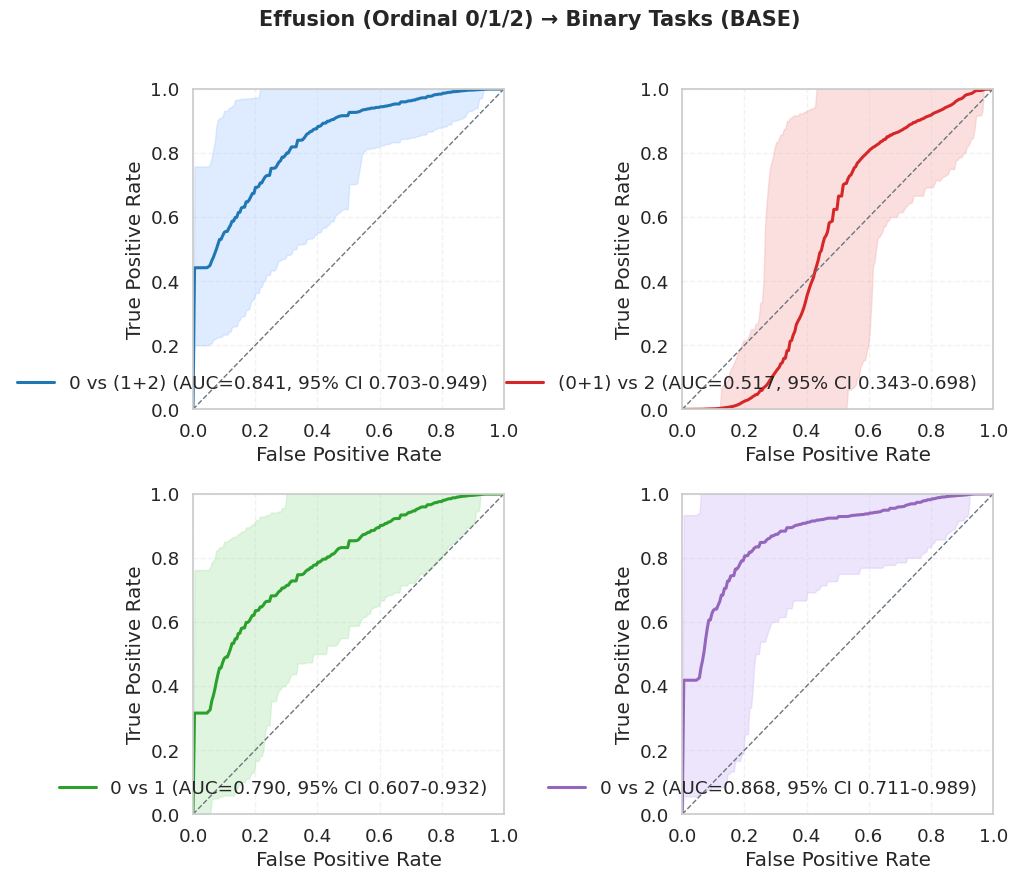

In [20]:

X_full = df.iloc[:, 3:15].copy()          # 설명변수 (E~Q 범위 예시)
y_ord  = df['Effusion grade'].astype(int) # 0/1/2

def make_binary_labels(y, task):
    """
    task:
      - '0_vs_12' : 0 vs (1+2)  → pos = (1 or 2)
      - '01_vs_2' : (0+1) vs 2  → pos = 2
      - '0_vs_1'  : 0 vs 1      → (2 제거), pos = 1
      - '0_vs_2'  : 0 vs 2      → (1 제거), pos = 2
    return: (mask, y_bin)  # mask는 X_full/y_ord에 적용할 행 필터
    """
    y = y.copy()
    if task == '0_vs_12':
        mask = y.isin([0,1,2])
        yb = (y > 0).astype(int)
    elif task == '01_vs_2':
        mask = y.isin([0,1,2])
        yb = (y == 2).astype(int)
    elif task == '0_vs_1':
        mask = y.isin([0,1])
        yb = (y == 1).astype(int)
    elif task == '0_vs_2':
        mask = y.isin([0,2])
        yb = (y == 2).astype(int)
    else:
        raise ValueError("Unknown task")
    return mask, yb

def fit_eval_binary(X, y_bin, test_size=0.2, random_state=42, n_boot=2000):

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_bin, test_size=test_size, stratify=y_bin, random_state=random_state
    )
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    clf = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=random_state)
    clf.fit(X_tr_sc, y_tr)
    y_score = clf.predict_proba(X_te_sc)[:, 1]

    auc_point = roc_auc_score(y_te, y_score)

    rng = np.random.RandomState(random_state)
    n = len(y_te)
    fpr_grid = np.linspace(0, 1, 200)
    auc_boot = []
    tprs = []

    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        y_bs = y_te.values[idx]
        s_bs = y_score[idx]

        if len(np.unique(y_bs)) < 2:
            continue
        auc_boot.append(roc_auc_score(y_bs, s_bs))
        fpr_i, tpr_i, _ = roc_curve(y_bs, s_bs)
        tpr_interp = np.interp(fpr_grid, fpr_i, tpr_i)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)

    if len(auc_boot) > 0:
        lo, hi = np.percentile(auc_boot, [2.5, 97.5])
    else:
        lo, hi = (np.nan, np.nan)

    tprs = np.array(tprs, dtype=float)
    if tprs.size > 0:
        tpr_mean  = np.nanmean(tprs, axis=0)
        tpr_lower = np.nanpercentile(tprs, 2.5, axis=0)
        tpr_upper = np.nanpercentile(tprs, 97.5, axis=0)
    else:
        tpr_mean = tpr_lower = tpr_upper = np.full_like(fpr_grid, np.nan)

    return {
        "auc": auc_point,
        "auc_ci": (lo, hi),
        "fpr_grid": fpr_grid,
        "tpr_mean": tpr_mean,
        "tpr_lower": tpr_lower,
        "tpr_upper": tpr_upper,
        "y_test": y_te,
        "y_score": y_score
    }


tasks = {
    "0 vs (1+2)" : "0_vs_12",
    "(0+1) vs 2" : "01_vs_2",
    "0 vs 1"     : "0_vs_1",
    "0 vs 2"     : "0_vs_2"
}

results = {}
for name, code in tasks.items():
    mask, yb = make_binary_labels(y_ord, code)
    X_use = X_full.loc[mask].fillna(0)
    y_use = yb.loc[mask]
    results[name] = fit_eval_binary(X_use, y_use, test_size=0.2, random_state=42, n_boot=2000)


rows = []
for name in tasks.keys():
    r = results[name]
    auc = r["auc"]; lo, hi = r["auc_ci"]
    n  = len(r["y_test"])
    pos = int(r["y_test"].sum())
    rows.append([name, auc, lo, hi, n, pos])

summary = pd.DataFrame(rows, columns=["Task","AUROC","AUROC_L","AUROC_U","N_test","Pos_in_test"])
print("\n=== BASE Results Summary (AUROC with 95% CI) ===")
print(summary.round(3).to_string(index=False))


colors_line = {
    "0 vs (1+2)": "#1f77b4",
    "(0+1) vs 2": "#d62728",
    "0 vs 1": "#2ca02c",
    "0 vs 2": "#9467bd"
}
colors_band = {
    "0 vs (1+2)": "#a6c8ff",
    "(0+1) vs 2": "#f4a6a6",
    "0 vs 1": "#a7e3a7",
    "0 vs 2": "#cdb7f6"
}

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()

for ax, name in zip(axes, tasks.keys()):
    r = results[name]
    fpr = r["fpr_grid"]; m = r["tpr_mean"]; lo = r["tpr_lower"]; hi = r["tpr_upper"]
    auc = r["auc"]; lci, uci = r["auc_ci"]

    if np.isfinite(lo).any():
        ax.fill_between(fpr, lo, hi, color=colors_band[name], alpha=0.35)

    ax.plot(fpr, m, color=colors_line[name], lw=2.2,
            label=f"{name} (AUC={auc:.3f}, 95% CI {lci:.3f}-{uci:.3f})")
    ax.plot([0,1],[0,1], "--", color="#6c757d", lw=1)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", frameon=False)
    ax.grid(alpha=0.25, linestyle="--")

fig.suptitle("Effusion (Ordinal 0/1/2) → Binary Tasks (BASE)", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()


SMOTE

In [18]:
print("Effusion (B) distribution:")
print(df['Effusion'].value_counts())

print("\nEffusion grade (C) distribution:")
print(df['Effusion grade'].value_counts())

Effusion (B) distribution:
Effusion
1    154
0     67
Name: count, dtype: int64

Effusion grade (C) distribution:
Effusion grade
1    90
0    67
2    64
Name: count, dtype: int64


Before SMOTE: {1: 123, 0: 53}
After SMOTE: {1: 123, 0: 123}
Effusion AUROC (with SMOTE): 0.8456221198156681


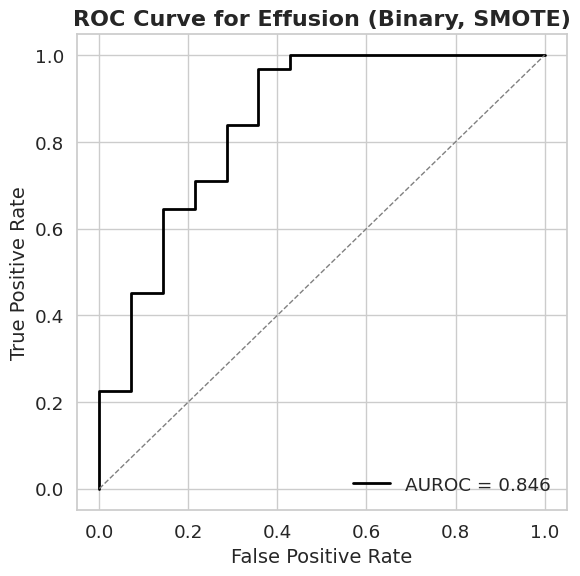

In [16]:
X = df.iloc[:, 4:17].fillna(0)
y = df['Effusion']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 🔹 SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sm, y_train_sm)

y_pred_proba = log_reg.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(y_test, y_pred_proba)
print("Effusion AUROC (with SMOTE):", auc_score)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,6))
sns.set(style="whitegrid", font_scale=1.2)
plt.plot(fpr, tpr, color="black", lw=2, label=f"AUROC = {auc_score:.3f}")
plt.plot([0,1],[0,1],"--",color="gray",lw=1)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve for Effusion (Binary, SMOTE)", fontsize=16, weight="bold")
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()


In [12]:

# Target = Effusion grade (0,1,2)
y_grade = df['Effusion grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_grade, test_size=0.2, random_state=42, stratify=y_grade)

# 🔹 SMOTE for multi-class
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

# Model Training (One-vs-Rest Logistic Regression)
clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
clf.fit(X_train_sm, y_train_sm)

# prediction
y_score = clf.predict_proba(X_test)

# Multi-class AUROC
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0,1,2])
auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print("Effusion Grade AUROC (macro):", auc_macro)
print("Effusion Grade AUROC (micro):", auc_micro)


Before SMOTE: {1: 72, 0: 53, 2: 51}
After SMOTE: {2: 72, 0: 72, 1: 72}
Effusion Grade AUROC (macro): 0.6550654683495184
Effusion Grade AUROC (micro): 0.671358024691358


Effusion / Effusion Grade & Full pipeline with CI + p-values (Colab-safe)


--------------------------------------------------------------------------------
BINARY: Effusion (0/1) — Base vs SMOTE
Base  AUROC = 0.841  (95% CI 0.703-0.949)
SMOTE AUROC = 0.853  (95% CI 0.722-0.961)
DeLong p-value (SMOTE vs Base): 1.0000


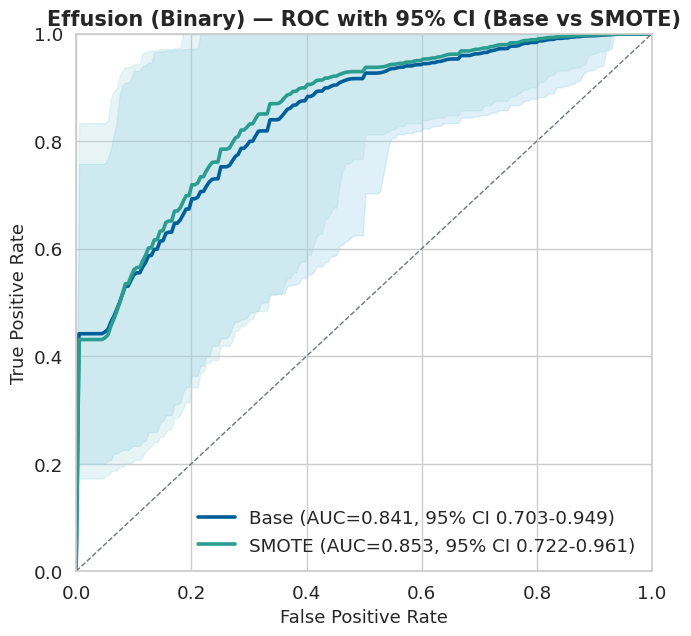


--------------------------------------------------------------------------------
MULTICLASS: Effusion grade (0/1/2) — Base vs SMOTE
Per-class AUROC (Base):  {0: np.float64(0.79), 1: np.float64(0.628), 2: np.float64(0.627)}
Per-class AUROC (SMOTE): {0: np.float64(0.788), 1: np.float64(0.679), 2: np.float64(0.582)}
Macro AUROC - Base: 0.682, SMOTE: 0.683
Micro AUROC - Base: 0.677, SMOTE: 0.678

--------------------------------------------------------------------------------
Multiclass comparison — bootstrap p-values
Macro diff mean: 0.002, 95% CI (np.float64(-0.053), np.float64(0.06)), p=0.9470
Micro diff mean: 0.001, 95% CI (np.float64(-0.049), np.float64(0.051)), p=0.9380
Class 0 diff mean: -0.002, 95% CI (np.float64(-0.03), np.float64(0.024)), p=0.9260
Class 1 diff mean: 0.053, 95% CI (np.float64(-0.055), np.float64(0.17)), p=0.3720
Class 2 diff mean: -0.044, 95% CI (np.float64(-0.141), np.float64(0.043)), p=0.3500


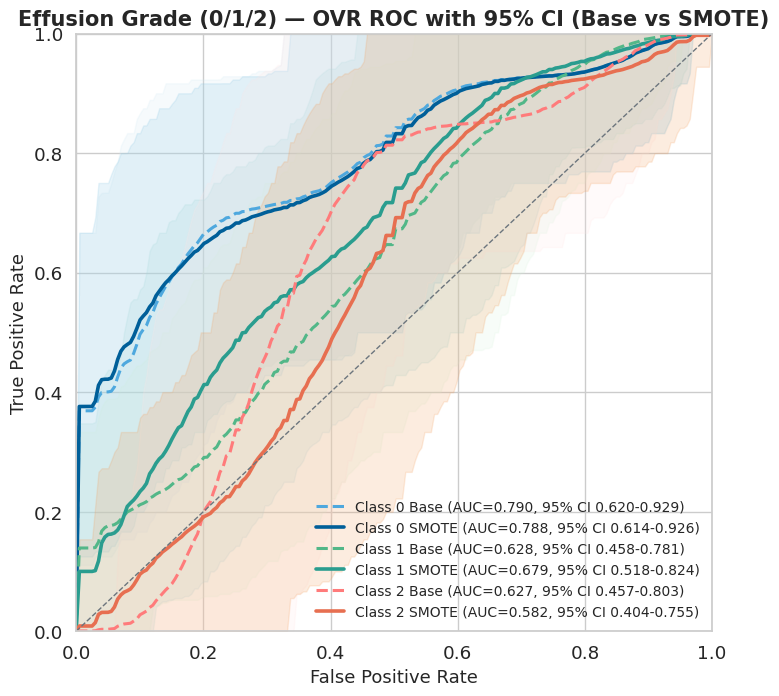


--------------------------------------------------------------------------------
Summary — Binary (DeLong), Multiclass (bootstrap)
Model  AUROC  CI_low  CI_high
 Base  0.841   0.703    0.949
SMOTE  0.853   0.722    0.961
DeLong p-value (SMOTE vs Base): 1.0000
     Metric  Base  SMOTE  Diff_mean(SMOTE-Base)  Diff_95%CI_low  Diff_95%CI_high  p_value
Macro AUROC 0.682  0.683                  0.002          -0.053            0.060    0.947
Micro AUROC 0.677  0.678                  0.001          -0.049            0.051    0.938
 Class  Base_AUROC  SMOTE_AUROC  Diff_mean  Diff_95%CI_low  Diff_95%CI_high  p_value
     0       0.790        0.788     -0.002          -0.030            0.024    0.926
     1       0.628        0.679      0.053          -0.055            0.170    0.372
     2       0.627        0.582     -0.044          -0.141            0.043    0.350


In [14]:
# ----------------------------
# Helper 0) Pretty print line
# ----------------------------
def line(msg=""):
    print("\n" + "-"*80)
    if msg:
        print(msg)


# ---------------------------------------------------
# Helper 1) DeLong's test (binary, pure python)
# ---------------------------------------------------
def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5*(i+j-1)+1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def _fastDeLong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    pos = predictions_sorted_transposed[:, :m]
    neg = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]
    aucs = []
    v01 = np.zeros((k, m))
    v10 = np.zeros((k, n))

    for r in range(k):
        v01[r, :] = _compute_midrank(pos[r, :])
        v10[r, :] = _compute_midrank(neg[r, :])
        aucs.append((v01[r, :].mean() - v10[r, :].mean())/(m*n))

    aucs = np.array(aucs)
    s01 = np.cov(v01)
    s10 = np.cov(v10)
    s = s01/m + s10/n
    return aucs, s

def delong_pvalue(y_true, pred1, pred2):
    """
    DeLong's test p-value for two correlated ROC AUCs.
    y_true: 0/1 array-like
    pred1, pred2: predicted probabilities for positive class
    """
    y_true = np.asarray(y_true).astype(int)
    order = np.argsort(-pred1)  # sort by first model scores descending
    y_true = y_true[order]
    preds = np.array([pred1, pred2])[:, order]
    label_1_count = int(np.sum(y_true))
    aucs, cov = _fastDeLong(preds, label_1_count)
    diff = aucs[0] - aucs[1]
    var = cov[0,0] + cov[1,1] - 2*cov[0,1]
    z = diff / (np.sqrt(var) + 1e-12)
    p = 2*stats.norm.sf(abs(z))
    return diff, p


# ---------------------------------------------------
# Helper 2) Bootstrap CI for AUC (binary)
# ---------------------------------------------------
def bootstrap_auc_ci(y_true, y_score, n_boot=2000, seed=42, alpha=0.95):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    aucs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt = y_true[idx]
        ys = y_score[idx]
        if len(np.unique(yt)) < 2:
            continue
        aucs.append(roc_auc_score(yt, ys))
    aucs = np.array(aucs)
    lo = np.percentile(aucs, (1-alpha)/2*100)
    hi = np.percentile(aucs, (1+(alpha))/2*100)
    return lo, hi, aucs


# ---------------------------------------------------
# Helper 3) Bootstrap ROC band (binary)
# ---------------------------------------------------
def bootstrap_roc_band(y_true, y_score, n_boot=2000, seed=42, grid_points=200):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n = len(y_true)
    fpr_grid = np.linspace(0, 1, grid_points)
    tprs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt = y_true[idx]
        ys = y_score[idx]
        if len(np.unique(yt)) < 2:
            continue
        fpr_b, tpr_b, _ = roc_curve(yt, ys)
        tpr_i = np.interp(fpr_grid, fpr_b, tpr_b)
        tpr_i[0] = 0.0
        tprs.append(tpr_i)
    tprs = np.array(tprs)
    return (
        fpr_grid,
        np.nanmean(tprs, axis=0),
        np.nanpercentile(tprs, 2.5, axis=0),
        np.nanpercentile(tprs, 97.5, axis=0)
    )


# ---------------------------------------------------
# Helper 4) Bootstrap CI & p-value for multiclass metrics
# (macro/micro & per-class OVR AUC, paired comparison Base vs SMOTE)
# ---------------------------------------------------
def multiclass_bootstrap_compare(y_true, proba_base, proba_smote, classes=(0,1,2), n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    n = len(y_true)

    diffs_macro, diffs_micro = [], []
    diffs_per_class = {c: [] for c in classes}

    macro_base_list, macro_smote_list = [], []
    micro_base_list, micro_smote_list = [], []
    per_class_base, per_class_smote = {c: [] for c in classes}, {c: [] for c in classes}

    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        y_bs = y_true[idx]
        yb_bin = label_binarize(y_bs, classes=classes)
        pb_base = proba_base[idx]
        pb_smote = proba_smote[idx]

        try:
            mac_b = roc_auc_score(yb_bin, pb_base, average="macro")
            mic_b = roc_auc_score(yb_bin, pb_base, average="micro")
            mac_s = roc_auc_score(yb_bin, pb_smote, average="macro")
            mic_s = roc_auc_score(yb_bin, pb_smote, average="micro")
        except ValueError:
            continue

        diffs_macro.append(mac_s - mac_b)
        diffs_micro.append(mic_s - mic_b)
        macro_base_list.append(mac_b); macro_smote_list.append(mac_s)
        micro_base_list.append(mic_b); micro_smote_list.append(mic_s)

        for i, c in enumerate(classes):
            yt_i = yb_bin[:, i]
            if len(np.unique(yt_i)) < 2:
                continue
            auc_b = roc_auc_score(yt_i, pb_base[:, i])
            auc_s = roc_auc_score(yt_i, pb_smote[:, i])
            diffs_per_class[c].append(auc_s - auc_b)
            per_class_base[c].append(auc_b)
            per_class_smote[c].append(auc_s)

    def ci(arr):
        return np.percentile(arr, 2.5), np.percentile(arr, 97.5)
    def pval(arr):
        arr = np.array(arr)
        return 2 * min((arr <= 0).mean(), (arr >= 0).mean())

    out = {}

    out['macro'] = {
        'diff_mean': float(np.mean(diffs_macro)) if len(diffs_macro) else np.nan,
        'diff_CI': ci(diffs_macro) if len(diffs_macro) else (np.nan, np.nan),
        'p_value': pval(diffs_macro) if len(diffs_macro) else np.nan,
        'base_CI': ci(macro_base_list) if len(macro_base_list) else (np.nan, np.nan),
        'smote_CI': ci(macro_smote_list) if len(macro_smote_list) else (np.nan, np.nan),
    }
    out['micro'] = {
        'diff_mean': float(np.mean(diffs_micro)) if len(diffs_micro) else np.nan,
        'diff_CI': ci(diffs_micro) if len(diffs_micro) else (np.nan, np.nan),
        'p_value': pval(diffs_micro) if len(diffs_micro) else np.nan,
        'base_CI': ci(micro_base_list) if len(micro_base_list) else (np.nan, np.nan),
        'smote_CI': ci(micro_smote_list) if len(micro_smote_list) else (np.nan, np.nan),
    }

    out['per_class'] = {}
    for c in classes:
        arr = diffs_per_class[c]
        out['per_class'][c] = {
            'diff_mean': float(np.mean(arr)) if len(arr) else np.nan,
            'diff_CI': ci(arr) if len(arr) else (np.nan, np.nan),
            'p_value': pval(arr) if len(arr) else np.nan,
            'base_CI': ci(per_class_base[c]) if len(per_class_base[c]) else (np.nan, np.nan),
            'smote_CI': ci(per_class_smote[c]) if len(per_class_smote[c]) else (np.nan, np.nan),
        }
    return out


# ---------------------------------------------------
# Helper 5) Per-class ROC band (OVR) for multiclass proba
# ---------------------------------------------------
def per_class_roc_band(y_true_bin, proba, classes=(0,1,2), seed=42, n_boot=2000, grid_points=200):
    rng = np.random.RandomState(seed)
    y_true_bin = np.asarray(y_true_bin)
    proba = np.asarray(proba)

    n = y_true_bin.shape[0]
    fpr_grid = np.linspace(0, 1, grid_points)
    out = {}

    for i, c in enumerate(classes):
        tprs = []
        for _ in range(n_boot):
            idx = rng.randint(0, n, n)
            yt = y_true_bin[idx, i]
            ys = proba[idx, i]
            if len(np.unique(yt)) < 2:
                continue
            fpr_b, tpr_b, _ = roc_curve(yt, ys)
            tpr_i = np.interp(fpr_grid, fpr_b, tpr_b)
            tpr_i[0] = 0.0
            tprs.append(tpr_i)

        tprs = np.array(tprs)
        out[c] = {
            'fpr_grid': fpr_grid,
            'tpr_mean': np.nanmean(tprs, axis=0),
            'tpr_low' : np.nanpercentile(tprs, 2.5, axis=0),
            'tpr_up'  : np.nanpercentile(tprs, 97.5, axis=0),
        }
    return out


# ---------------------------------------------------
# Helper 6) Per-class AUC CI (bootstrap) for multiclass proba
# ---------------------------------------------------
def per_class_auc_ci(y_true_bin, proba, classes=(0,1,2), seed=42, n_boot=2000, alpha=0.95):
    rng = np.random.RandomState(seed)
    y_true_bin = np.asarray(y_true_bin)
    proba = np.asarray(proba)

    n = y_true_bin.shape[0]
    ci = {}

    for i, c in enumerate(classes):
        aucs = []
        for _ in range(n_boot):
            idx = rng.randint(0, n, n)
            yt = y_true_bin[idx, i]
            ys = proba[idx, i]
            if len(np.unique(yt)) < 2:
                continue
            aucs.append(roc_auc_score(yt, ys))

        if len(aucs):
            lo = np.percentile(aucs, (1-alpha)/2*100)
            hi = np.percentile(aucs, (1+(alpha))/2*100)
            ci[c] = (lo, hi)
        else:
            ci[c] = (np.nan, np.nan)
    return ci


# =========================
# 0) Load your df (필요시)
# =========================
# df = pd.read_excel("YOUR_FILE.xlsx")  # <- already loaded in your notebook


# =========================
# 1) Binary: Effusion (0/1)
# =========================
line("BINARY: Effusion (0/1) — Base vs SMOTE")

y_bin_out = df['Effusion'].astype(int)
X_feat    = df.iloc[:, 3:15].fillna(0)  # Sex(Female) ~ Bruxism

X_tr, X_te, y_tr, y_te = train_test_split(
    X_feat, y_bin_out, test_size=0.2, random_state=42, stratify=y_bin_out
)

# ----- Base model -----
sc_base = StandardScaler().fit(X_tr)
X_tr_b = sc_base.transform(X_tr)
X_te_b = sc_base.transform(X_te)

m_base = LogisticRegression(max_iter=1000, random_state=42)
m_base.fit(X_tr_b, y_tr)
proba_base = m_base.predict_proba(X_te_b)[:, 1]

auc_base = roc_auc_score(y_te, proba_base)
ciL_b, ciU_b, boot_b = bootstrap_auc_ci(y_te, proba_base, n_boot=2000, seed=42)

# ----- SMOTE model -----
sm = SMOTE(random_state=42)
X_tr_s, y_tr_s = sm.fit_resample(X_tr, y_tr)

sc_sm = StandardScaler().fit(X_tr_s)
X_tr_s_sc = sc_sm.transform(X_tr_s)
X_te_s_sc = sc_sm.transform(X_te)

m_sm = LogisticRegression(max_iter=1000, random_state=42)
m_sm.fit(X_tr_s_sc, y_tr_s)
proba_sm = m_sm.predict_proba(X_te_s_sc)[:, 1]

auc_sm = roc_auc_score(y_te, proba_sm)
ciL_s, ciU_s, boot_s = bootstrap_auc_ci(y_te, proba_sm, n_boot=2000, seed=42)

# ----- DeLong test -----
diff_auc, p_delong = delong_pvalue(y_te, proba_sm, proba_base)

print(f"Base  AUROC = {auc_base:.3f}  (95% CI {ciL_b:.3f}-{ciU_b:.3f})")
print(f"SMOTE AUROC = {auc_sm:.3f}  (95% CI {ciL_s:.3f}-{ciU_s:.3f})")
print(f"DeLong p-value (SMOTE vs Base): {p_delong:.4f}")

# ----- Plot: Base vs SMOTE, both with CI bands -----
fpr_b, mean_b, low_b, up_b = bootstrap_roc_band(y_te, proba_base, n_boot=2000, seed=42)
fpr_s, mean_s, low_s, up_s = bootstrap_roc_band(y_te, proba_sm,   n_boot=2000, seed=42)

plt.figure(figsize=(7.0, 6.6))
plt.fill_between(fpr_b, low_b, up_b, color="#8ecae6", alpha=0.28)
plt.plot(fpr_b, mean_b, color="#005f99", lw=2.6,
         label=f"Base (AUC={auc_base:.3f}, 95% CI {ciL_b:.3f}-{ciU_b:.3f})")

plt.fill_between(fpr_s, low_s, up_s, color="#a8dadc", alpha=0.28)
plt.plot(fpr_s, mean_s, color="#2a9d8f", lw=2.6,
         label=f"SMOTE (AUC={auc_sm:.3f}, 95% CI {ciL_s:.3f}-{ciU_s:.3f})")

plt.plot([0,1],[0,1], "--", color="#6c757d", lw=1)
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("Effusion (Binary) — ROC with 95% CI (Base vs SMOTE)", fontsize=15, fontweight="bold")
plt.xlim(0,1); plt.ylim(0,1)
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()


# ========================================
# 2) Multiclass: Effusion grade (0/1/2)
# ========================================
line("MULTICLASS: Effusion grade (0/1/2) — Base vs SMOTE")

classes = [0,1,2]
y_mc_out = df['Effusion grade'].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_feat, y_mc_out, test_size=0.2, random_state=42, stratify=y_mc_out
)

# ----- Base OVR Logistic -----
sc_b = StandardScaler().fit(X_tr)
X_tr_b = sc_b.transform(X_tr)
X_te_b = sc_b.transform(X_te)

ovr_b = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
ovr_b.fit(X_tr_b, y_tr)
proba_b = ovr_b.predict_proba(X_te_b)   # (n,3)

y_te_bin = label_binarize(y_te, classes=classes)

auc_b_per = {c: roc_auc_score(y_te_bin[:,i], proba_b[:,i]) for i,c in enumerate(classes)}
auc_b_macro = roc_auc_score(y_te_bin, proba_b, average="macro")
auc_b_micro = roc_auc_score(y_te_bin, proba_b, average="micro")

# ----- SMOTE OVR Logistic -----
sm = SMOTE(random_state=42)
X_tr_s, y_tr_s = sm.fit_resample(X_tr, y_tr)

sc_s = StandardScaler().fit(X_tr_s)
X_tr_s_sc = sc_s.transform(X_tr_s)
X_te_s_sc = sc_s.transform(X_te)

ovr_s = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
ovr_s.fit(X_tr_s_sc, y_tr_s)
proba_s = ovr_s.predict_proba(X_te_s_sc)

auc_s_per = {c: roc_auc_score(y_te_bin[:,i], proba_s[:,i]) for i,c in enumerate(classes)}
auc_s_macro = roc_auc_score(y_te_bin, proba_s, average="macro")
auc_s_micro = roc_auc_score(y_te_bin, proba_s, average="micro")

print("Per-class AUROC (Base): ", {k: round(v,3) for k,v in auc_b_per.items()})
print("Per-class AUROC (SMOTE):", {k: round(v,3) for k,v in auc_s_per.items()})
print(f"Macro AUROC - Base: {auc_b_macro:.3f}, SMOTE: {auc_s_macro:.3f}")
print(f"Micro AUROC - Base: {auc_b_micro:.3f}, SMOTE: {auc_s_micro:.3f}")

# ----- Bootstrap paired comparison: macro/micro & per-class -----
mc_cmp = multiclass_bootstrap_compare(y_te, proba_b, proba_s, classes=classes, n_boot=2000, seed=42)

line("Multiclass comparison — bootstrap p-values")
print(f"Macro diff mean: {mc_cmp['macro']['diff_mean']:.3f}, 95% CI {tuple(round(x,3) for x in mc_cmp['macro']['diff_CI'])}, p={mc_cmp['macro']['p_value']:.4f}")
print(f"Micro diff mean: {mc_cmp['micro']['diff_mean']:.3f}, 95% CI {tuple(round(x,3) for x in mc_cmp['micro']['diff_CI'])}, p={mc_cmp['micro']['p_value']:.4f}")
for c in classes:
    d = mc_cmp['per_class'][c]
    print(f"Class {c} diff mean: {d['diff_mean']:.3f}, 95% CI {tuple(round(x,3) for x in d['diff_CI'])}, p={d['p_value']:.4f}")

# ----------------------------------------------------
# Plot: Multiclass OVR ROC (Base + SMOTE together)
# -> total 6 lines (each class: Base dashed + SMOTE solid)
# -> class 0=blue, 1=green, 2=red families
# ----------------------------------------------------
bands_b = per_class_roc_band(y_te_bin, proba_b, classes=classes, seed=42, n_boot=2000, grid_points=200)
bands_s = per_class_roc_band(y_te_bin, proba_s, classes=classes, seed=42, n_boot=2000, grid_points=200)

ci_b_perclass = per_class_auc_ci(y_te_bin, proba_b, classes=classes, seed=42, n_boot=2000)
ci_s_perclass = per_class_auc_ci(y_te_bin, proba_s, classes=classes, seed=42, n_boot=2000)

# colors: Base (lighter + dashed), SMOTE (darker + solid)
line_base  = {0: "#4ea8de", 1: "#52b788", 2: "#ff7b7b"}
line_smote = {0: "#005f99", 1: "#2a9d8f", 2: "#e76f51"}

band_base  = {0: "#cfe8f3", 1: "#d8f3dc", 2: "#ffe5e5"}
band_smote = {0: "#8ecae6", 1: "#a8dadc", 2: "#f4a261"}

plt.figure(figsize=(7.6, 7.2))

for c in classes:
    # ---- Base
    grd = bands_b[c]['fpr_grid']
    mean= bands_b[c]['tpr_mean']
    low = bands_b[c]['tpr_low']
    up  = bands_b[c]['tpr_up']

    plt.fill_between(grd, low, up, color=band_base[c], alpha=0.18)
    lo, hi = ci_b_perclass[c]
    plt.plot(
        grd, mean, color=line_base[c], lw=2.2, ls="--",
        label=f"Class {c} Base (AUC={auc_b_per[c]:.3f}, 95% CI {lo:.3f}-{hi:.3f})"
    )

    # ---- SMOTE
    grd = bands_s[c]['fpr_grid']
    mean= bands_s[c]['tpr_mean']
    low = bands_s[c]['tpr_low']
    up  = bands_s[c]['tpr_up']

    plt.fill_between(grd, low, up, color=band_smote[c], alpha=0.20)
    lo, hi = ci_s_perclass[c]
    plt.plot(
        grd, mean, color=line_smote[c], lw=2.6, ls="-",
        label=f"Class {c} SMOTE (AUC={auc_s_per[c]:.3f}, 95% CI {lo:.3f}-{hi:.3f})"
    )

plt.plot([0,1],[0,1], "--", color="#6c757d", lw=1)
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("Effusion Grade (0/1/2) — OVR ROC with 95% CI (Base vs SMOTE)", fontsize=15, fontweight="bold")
plt.xlim(0,1); plt.ylim(0,1)
plt.legend(loc="lower right", frameon=False, fontsize=10)
plt.tight_layout()
plt.show()


# ----- Summary tables (concise) -----
line("Summary — Binary (DeLong), Multiclass (bootstrap)")

binary_summary = pd.DataFrame([{
    "Model": "Base",  "AUROC": round(auc_base,3),  "CI_low": round(ciL_b,3), "CI_high": round(ciU_b,3)
},{
    "Model": "SMOTE", "AUROC": round(auc_sm,3),    "CI_low": round(ciL_s,3), "CI_high": round(ciU_s,3)
}])
print(binary_summary.to_string(index=False))
print(f"DeLong p-value (SMOTE vs Base): {p_delong:.4f}")

multi_summary = pd.DataFrame([
    {"Metric": "Macro AUROC", "Base": round(auc_b_macro,3), "SMOTE": round(auc_s_macro,3),
     "Diff_mean(SMOTE-Base)": round(mc_cmp['macro']['diff_mean'],3),
     "Diff_95%CI_low": round(mc_cmp['macro']['diff_CI'][0],3),
     "Diff_95%CI_high": round(mc_cmp['macro']['diff_CI'][1],3),
     "p_value": round(mc_cmp['macro']['p_value'],4)},
    {"Metric": "Micro AUROC", "Base": round(auc_b_micro,3), "SMOTE": round(auc_s_micro,3),
     "Diff_mean(SMOTE-Base)": round(mc_cmp['micro']['diff_mean'],3),
     "Diff_95%CI_low": round(mc_cmp['micro']['diff_CI'][0],3),
     "Diff_95%CI_high": round(mc_cmp['micro']['diff_CI'][1],3),
     "p_value": round(mc_cmp['micro']['p_value'],4)},
])
print(multi_summary.to_string(index=False))

perclass_rows = []
for c in classes:
    d = mc_cmp['per_class'][c]
    perclass_rows.append({
        "Class": c,
        "Base_AUROC": round(auc_b_per[c],3),
        "SMOTE_AUROC": round(auc_s_per[c],3),
        "Diff_mean": round(d['diff_mean'],3),
        "Diff_95%CI_low": round(d['diff_CI'][0],3),
        "Diff_95%CI_high": round(d['diff_CI'][1],3),
        "p_value": round(d['p_value'],4)
    })
print(pd.DataFrame(perclass_rows).to_string(index=False))


BASE vs STOME comparison


=========== BASE: Binary Results (AUROC with 95% CI) ===========
     Scheme  AUROC  AUROC_L  AUROC_U   N  Pos
       0vs1  0.823    0.668    0.978 221  154
0_vs_1plus2  0.823    0.668    0.978 221  154
    01_vs_2  0.743    0.571    0.915 221   64

=========== BASE: Ordinal (one-vs-rest AUROC) ===========
 class0  class1  class2
  0.812   0.554   0.713
Macro-AUROC (BASE, ordinal): 0.693

[Binary] BASE vs STOME: Comparison omitted as one side is missing

[Ordinal] BASE vs STOME: Comparison omitted as one side is missing


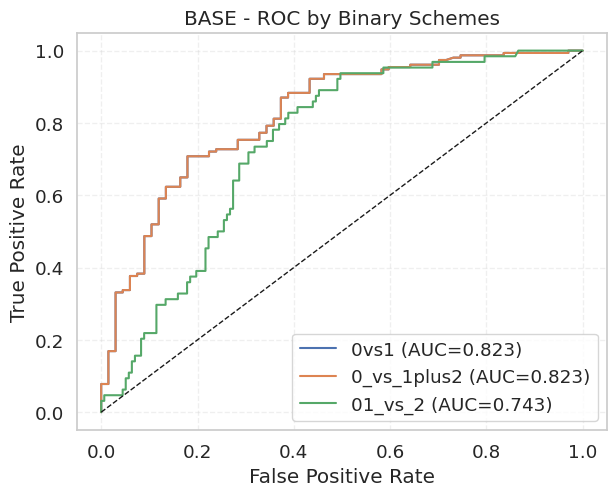


--- Decision helper (BASE) ---
AUC[0 vs 1]        = 0.823
AUC[0 vs (1+2)]    = 0.823
Macro-AUC[ordinal] = 0.693
⇒ Differences exist: It is safer to report both Level 2 and Level 3.


In [22]:
# ================================================================
# Effusion: 0 vs 1 (Binary), 0/1/2 (Ordinal),
# Additional binary schemes (0+1 vs 2, 0 vs 1+2) + BASE vs STOME comparison (DeLong)
# ================================================================

PHASE_COL   = "Phase"
BASE_VALUE  = "BASE"
STOME_VALUE = "STOME"

FEATURES = [
    'Age','ADD','VAS','Symptom duration','TMJ noise',
    'Locking','Muscle stiffness','Tinnitus','Bruxism'
]
FEATURES = [c for c in FEATURES if c in df.columns]
CONT_COLS = [c for c in ['Age','VAS','Symptom duration'] if c in FEATURES]

BIN_COL   = 'Effusion'        # 0/1
ORD_COL   = 'Effusion grade'  # 0/1/2

# -------------------------------
# 1) DeLong AUC
# -------------------------------
def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5*(i + j - 1) + 1
        i = j
    out = np.empty(N, dtype=float)
    out[J] = T
    return out

def _fast_delong(scores, labels):
    # labels: 1=positive, 0=negative
    order = np.argsort(-scores)
    scores = scores[order]
    labels = labels[order]
    n1 = np.sum(labels==1)
    n2 = np.sum(labels==0)
    tx = _compute_midrank(scores)
    t1 = tx[labels==1]
    t2 = tx[labels==0]
    auc = (t1.sum() - n1*(n1+1)/2) / (n1*n2)
    v01 = (t1 - (n1+1)/2) / n2
    v10 = 1 - (t2 - (n1+1)/2) / n1
    s01 = np.var(v01, ddof=1)
    s10 = np.var(v10, ddof=1)
    se_auc = np.sqrt(s01/n1 + s10/n2)
    return auc, se_auc

def delong_test_auc(scores_a, scores_b, labels):

    auc_a, se_a = _fast_delong(np.asarray(scores_a), np.asarray(labels))
    auc_b, se_b = _fast_delong(np.asarray(scores_b), np.asarray(labels))
    se_delta = np.sqrt(se_a**2 + se_b**2)
    delta = auc_a - auc_b
    if se_delta == 0:
        z = np.inf if delta>0 else -np.inf if delta<0 else 0.0
        p = 0.0 if delta!=0 else 1.0
    else:
        from math import erf, sqrt
        z = delta / se_delta
        p = 2*(1 - 0.5*(1 + erf(abs(z)/sqrt(2))))
    return auc_a, auc_b, delta, z, p

def auc_ci_delong(scores, labels, alpha=0.05):
    auc, se = _fast_delong(np.asarray(scores), np.asarray(labels))

    from math import sqrt
    # z_{1-alpha/2} (alpha=0.05 → 1.96)
    z = 1.959964
    lo = max(0.0, auc - z*se)
    hi = min(1.0, auc + z*se)
    return auc, (lo, hi)


def make_label_binary_from_ord(series, scheme):
    """
    scheme:
      - "0_vs_1plus2": 0 vs (1,2)=1
      - "01_vs_2": (0,1)=0 vs 2=1
    """
    s = series.astype(int)
    if scheme == "0_vs_1plus2":
        return (s > 0).astype(int)
    elif scheme == "01_vs_2":
        return (s == 2).astype(int)
    else:
        raise ValueError("Unknown scheme")


def fit_logit_auc(X, y):
    """statsmodels Logit -> 예측확률 -> AUROC"""
    Xc = sm.add_constant(X, has_constant='add')
    model = sm.Logit(y, Xc)
    try:
        res = model.fit(disp=False)
    except Exception:
        res = model.fit_regularized(alpha=0.1, L1_wt=0.0, disp=False)
    pred = res.predict(Xc)  # P(y=1)
    auc = roc_auc_score(y, pred)
    return res, pred, auc

def fit_ordinal_auc(X, y_ord):
    """
    OrderedModel(logit) -> 각 클래스(0/1/2) vs rest AUC 계산
    return: res, preds (n x 3 proba), auc_dict{"class0","class1","class2"}
    """
    model = OrderedModel(y_ord, X, distr='logit')
    try:
        res = model.fit(method='bfgs', disp=False)
    except Exception:
        res = model.fit_regularized(method='l1', alpha=0.1, disp=False)


    pred_proba = np.asarray(res.model.predict(res.params))
    aucs = {}
    n_classes = pred_proba.shape[1]
    for cls in range(n_classes):
        y_bin = (y_ord == cls).astype(int)
        p_cls = pred_proba[:, cls]
        aucs[f"class{cls}"] = roc_auc_score(y_bin, p_cls)
    return res, pred_proba, aucs

# -------------------------------
# 4) Analysis Pipeline
# -------------------------------
def prepare_Xy(df_part):
    dat = df_part.copy()
    dat = dat.dropna(subset=FEATURES).copy()
    if CONT_COLS:
        scaler = StandardScaler()
        dat.loc[:, CONT_COLS] = scaler.fit_transform(dat[CONT_COLS])
    X = dat[FEATURES]
    return dat, X

def run_binary_schemes(df_part):

    out = {}
    dat, X = prepare_Xy(df_part)

    # (a) 0 vs 1
    if BIN_COL in dat.columns:
        y01 = dat[BIN_COL].astype(int)
    elif ORD_COL in dat.columns:
        y01 = (dat[ORD_COL].astype(int) > 0).astype(int)   # 0 vs (1,2)
    else:
        y01 = None

    if y01 is not None:
        res01, pred01, auc01 = fit_logit_auc(X, y01)
        out["0vs1"] = {"res":res01, "pred":pred01, "auc":auc01, "y":y01}

    # (b) 0 vs (1+2)
    if ORD_COL in dat.columns:
        y0v12 = make_label_binary_from_ord(dat[ORD_COL], "0_vs_1plus2")
        res0v12, pred0v12, auc0v12 = fit_logit_auc(X, y0v12)
        out["0_vs_1plus2"] = {"res":res0v12, "pred":pred0v12, "auc":auc0v12, "y":y0v12}

        # (c) (0+1) vs 2
        y01v2 = make_label_binary_from_ord(dat[ORD_COL], "01_vs_2")
        res01v2, pred01v2, auc01v2 = fit_logit_auc(X, y01v2)
        out["01_vs_2"] = {"res":res01v2, "pred":pred01v2, "auc":auc01v2, "y":y01v2}

    return out

def run_ordinal(df_part):
    if ORD_COL not in df_part.columns:
        return None
    dat, X = prepare_Xy(df_part)
    dat = dat.dropna(subset=[ORD_COL]).copy()
    y_ord = dat[ORD_COL].astype(int)
    res, pred_proba, aucs = fit_ordinal_auc(X, y_ord)
    return {"res":res, "proba":pred_proba, "aucs":aucs, "y":y_ord}

# -------------------------------
# 5) BASE / STOME eparation
# -------------------------------
def split_base_stome(df):
    if PHASE_COL in df.columns:
        g = df[PHASE_COL].astype(str)
        base_df  = df[g==BASE_VALUE].copy()
        stome_df = df[g==STOME_VALUE].copy()
        if len(base_df)==0:  base_df = None
        if len(stome_df)==0: stome_df = None
        return base_df, stome_df
    else:
        return df.copy(), None

# -------------------------------
# 6) Run + Output
# -------------------------------
base_df, stome_df = split_base_stome(df)

def summarize_binary_results(tag, resdict):
    print(f"\n=========== {tag}: Binary Results (AUROC with 95% CI) ===========")
    rows = []
    for k, v in resdict.items():
        auc = v["auc"]
        y   = v["y"].values
        scores = v["pred"]
        auc_, (lo, hi) = auc_ci_delong(scores, y, alpha=0.05)
        rows.append([k, auc_, lo, hi, len(y), int(y.sum())])
    out = pd.DataFrame(rows, columns=["Scheme","AUROC","AUROC_L","AUROC_U","N","Pos"])
    print(out.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    return out

def compare_base_stome_binary(base_res, stome_res):
    """ BASE vs STOME AUROC DeLong 비교"""
    if (base_res is None) or (stome_res is None):
        print("\n[Binary] BASE vs STOME: Comparison omitted as one side is missing")
        return None
    print("\n=========== BASE vs STOME (Binary, DeLong) ===========")
    rows = []
    common = set(base_res.keys()) & set(stome_res.keys())
    for k in sorted(common):
        y_b, sc_b = base_res[k]["y"].values, base_res[k]["pred"]
        y_s, sc_s = stome_res[k]["y"].values, stome_res[k]["pred"]

        auc_b, auc_s, delta, z, p = delong_test_auc(sc_b, sc_s, y_b)
        rows.append([k, auc_b, auc_s, delta, z, p, len(y_b), len(y_s)])
    out = pd.DataFrame(rows, columns=["Scheme","AUROC_BASE","AUROC_STOME","Delta","z","p_value","N_BASE","N_STOME"])
    print(out.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    return out

def summarize_ordinal_results(tag, ordres):
    if ordres is None:
        print(f"\n[{tag}] Ordinal: No target column")
        return None
    print(f"\n=========== {tag}: Ordinal (one-vs-rest AUROC) ===========")
    aucs = ordres["aucs"]
    out = pd.DataFrame([aucs])
    print(out.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    macro = np.mean(list(aucs.values()))
    print(f"Macro-AUROC ({tag}, ordinal): {macro:.3f}")
    return out, macro

def compare_base_stome_ordinal(base_ord, stome_ord):
    """Ordinal: class-wise one-vs-rest Compare AUROC using independent sample approximation"""
    if (base_ord is None) or (stome_ord is None):
        print("\n[Ordinal] BASE vs STOME: Comparison omitted as one side is missing")
        return None
    print("\n=========== BASE vs STOME (Ordinal, DeLong by class) ===========")
    rows = []

    for cls in [0,1,2]:
        # BASE
        yb = (base_ord["y"] == cls).astype(int).values
        pb = base_ord["proba"][:, cls]
        # STOME
        ys = (stome_ord["y"] == cls).astype(int).values
        ps = stome_ord["proba"][:, cls]
        auc_b, auc_s, delta, z, p = delong_test_auc(pb, ps, yb)
        rows.append([f"class{cls}", auc_b, auc_s, delta, z, p, len(yb), len(ys)])
    out = pd.DataFrame(rows, columns=["Class","AUROC_BASE","AUROC_STOME","Delta","z","p_value","N_BASE","N_STOME"])
    print(out.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    return out

# ---- BASE ----
if base_df is not None:
    base_bin = run_binary_schemes(base_df)
    base_ord = run_ordinal(base_df)
    base_bin_tbl = summarize_binary_results("BASE", base_bin)
    base_ord_tbl, base_ord_macro = summarize_ordinal_results("BASE", base_ord)
else:
    base_bin = base_ord = base_bin_tbl = base_ord_tbl = None
    base_ord_macro = np.nan

# ---- STOME ----
if stome_df is not None:
    stome_bin = run_binary_schemes(stome_df)
    stome_ord = run_ordinal(stome_df)
    stome_bin_tbl = summarize_binary_results("STOME", stome_bin)
    stome_ord_tbl, stome_ord_macro = summarize_ordinal_results("STOME", stome_ord)
else:
    stome_bin = stome_ord = stome_bin_tbl = stome_ord_tbl = None
    stome_ord_macro = np.nan

# ---- BASE vs STOME 비교 ----
bin_compare_tbl   = compare_base_stome_binary(base_bin, stome_bin)
ord_compare_tbl   = compare_base_stome_ordinal(base_ord, stome_ord)

# -------------------------------
# 7) (선택) ROC Curve Visualization example
# -------------------------------
def plot_roc_curves(resdict, title="ROC Curves (Binary schemes)"):
    if not resdict: return
    plt.figure(figsize=(6.4,5.2))
    for k, v in resdict.items():
        y = v["y"].values
        sc = v["pred"]
        fpr, tpr, _ = roc_curve(y, sc)
        auc = roc_auc_score(y, sc)
        plt.plot(fpr, tpr, label=f"{k} (AUC={auc:.3f})")
    plt.plot([0,1],[0,1],'k--',lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(title); plt.legend(); plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout(); plt.show()

if base_bin:
    plot_roc_curves(base_bin, "BASE - ROC by Binary Schemes")
if stome_bin:
    plot_roc_curves(stome_bin, "STOME - ROC by Binary Schemes")


if base_bin and ("0vs1" in base_bin) and ("0_vs_1plus2" in base_bin) and (not np.isnan(base_ord_macro)):
    auc_0vs1       = base_bin["0vs1"]["auc"]
    auc_0v12       = base_bin["0_vs_1plus2"]["auc"]
    macro_ord_base = base_ord_macro
    print("\n--- Decision helper (BASE) ---")
    print(f"AUC[0 vs 1]        = {auc_0vs1:.3f}")
    print(f"AUC[0 vs (1+2)]    = {auc_0v12:.3f}")
    print(f"Macro-AUC[ordinal] = {macro_ord_base:.3f}")

    if max(abs(auc_0vs1-macro_ord_base), abs(auc_0v12-macro_ord_base)) <= 0.02:
        print("⇒ No significant difference between Stage 2 and Stage 3: Recommendation to present subsequent analysis based on Stage 3 (ordinal).")
    else:
        print("⇒ Differences exist: It is safer to report both Level 2 and Level 3.")
